In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 0 = free cell
# 1 = wall
# 2 = hole (terminal, negative reward)
# 3 = goal (terminal, positive reward)

maze = np.array([
    [0, 0, 1, 0, 0, 0],
    [0, 2, 0, 0, 1, 0],
    [0, 0, 0, 2, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [2, 0, 1, 0, 0, 3]
])

ROWS, COLS = maze.shape
START = (0, 0)
GOAL  = (5, 5)

In [3]:
# shape: (rows, cols, 4 actions)
Q = np.zeros((ROWS, COLS, 4))

In [4]:
alpha   = 0.5   # learning rate
gamma   = 0.9   # discount factor
epsilon = 0.2   # exploration rate
episodes = 500  

In [5]:
# action directions: 0=up, 1=down, 2=left, 3=right
DIRS = [(-1,0), (1,0), (0,-1), (0,1)]

def step(state, action):
    r, c = state
    dr, dc = DIRS[action]
    nr, nc = r + dr, c + dc

    # if move goes out of bounds or into wall, stay put
    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS or maze[nr, nc] == 1:
        nr, nc = r, c

    # assign reward based on what the next cell is
    tile = maze[nr, nc]
    if tile == 3:
        reward = 10       # reached goal
    elif tile == 2:
        reward = -1       # fell in hole
    else:
        reward = -0.04    # normal move — small penalty encourages efficiency

    done = (tile == 3 or tile == 2)
    return (nr, nc), reward, done

In [6]:
def choose_action(state):
    r, c = state
    if np.random.random() < epsilon:
        return np.random.randint(4)           # random action
    else:
        return np.argmax(Q[r, c])             # best known action

In [7]:
steps_per_episode = []
deltas_over_time  = []

for episode in range(episodes):
    state = START
    steps = 0

    while True:
        r, c = state

        # select action
        action = choose_action(state)

        # execute action
        next_state, reward, done = step(state, action)
        nr, nc = next_state

        # compute TD error
        delta = reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]

        # update Q table
        Q[r, c, action] += alpha * delta

        # record
        deltas_over_time.append(delta)
        steps += 1
        state = next_state

        if done or steps > 500:
            break

    steps_per_episode.append(steps)

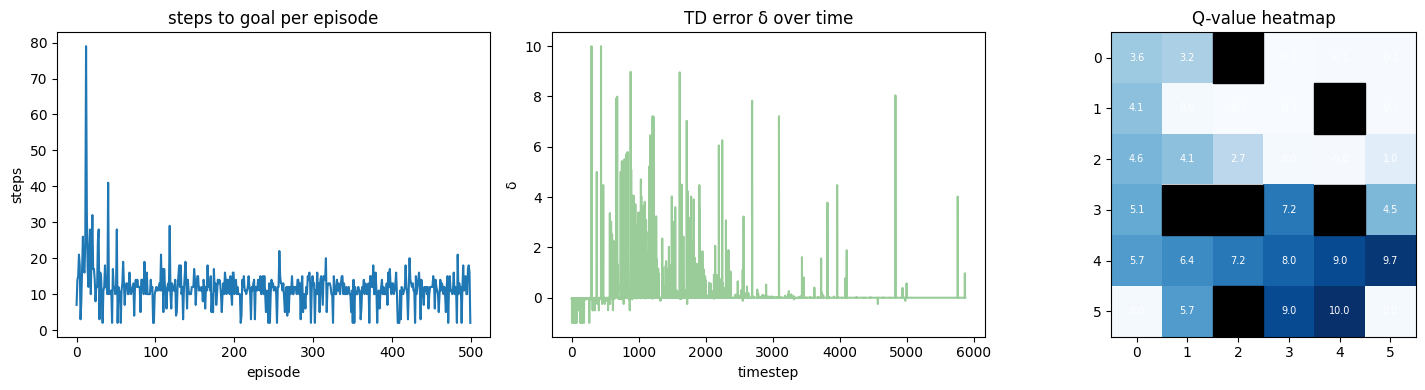

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. learning curve
axes[0].plot(steps_per_episode)
axes[0].set_title('steps to goal per episode')
axes[0].set_xlabel('episode')
axes[0].set_ylabel('steps')

# 2. TD error over time
axes[1].plot(deltas_over_time, alpha=0.4, color='green')
axes[1].set_title('TD error δ over time')
axes[1].set_xlabel('timestep')
axes[1].set_ylabel('δ')

# 3. Q-value heatmap
value_map = np.max(Q, axis=2)   # best Q value at each cell
axes[2].imshow(value_map, cmap='Blues')
axes[2].set_title('Q-value heatmap')
for r in range(ROWS):
    for c in range(COLS):
        if maze[r, c] == 1:
            axes[2].add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))
        else:
            axes[2].text(c, r, f'{value_map[r,c]:.1f}',
                        ha='center', va='center', fontsize=7, color='white')

plt.tight_layout()
plt.show()

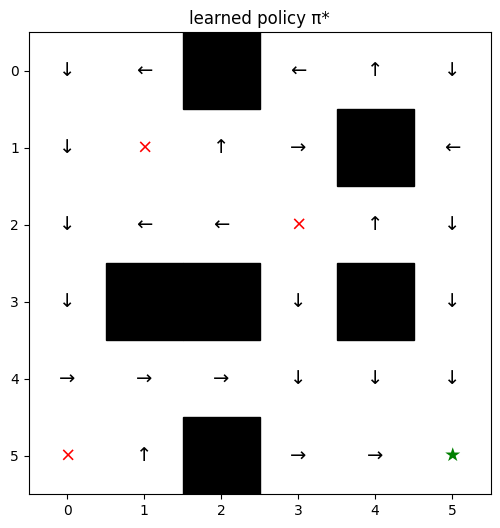

In [9]:
arrow_map = {0:'↑', 1:'↓', 2:'←', 3:'→'}

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.zeros((ROWS, COLS)), cmap='Greys', vmin=0, vmax=1)

for r in range(ROWS):
    for c in range(COLS):
        if maze[r, c] == 1:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))
        elif maze[r, c] == 3:
            ax.text(c, r, '★', ha='center', va='center', fontsize=14, color='green')
        elif maze[r, c] == 2:
            ax.text(c, r, '×', ha='center', va='center', fontsize=14, color='red')
        else:
            best_action = np.argmax(Q[r, c])
            ax.text(c, r, arrow_map[best_action],
                   ha='center', va='center', fontsize=14)

ax.set_title('learned policy π*')
ax.set_xticks(range(COLS))
ax.set_yticks(range(ROWS))
plt.show()